# Readme
1. Convert point lat/lon into dataframe
2. Consolidate all pathways into one dataframe
3. Make scatter plot of points onto subregion of interest; output is all forest response pathways mapped onto subregion of internest
4. Show relative distribution of pathways; output is a pie chart of forest response pathway distributio
5. Plot all data points (iresspective of forest response path)
6. Plot points classified as upland forest (note: no tracks)
7. Make 4 Panel Figure for Region of Interest

## Import Libraries

In [2]:
import xarray as xr
from pyproj import Transformer
from shapely.ops import transform
from shapely.geometry import Point
import numpy as np
from geopandas import GeoSeries
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point
from pyproj import Transformer
from shapely.ops import transform
import csv 
import pandas as pd
import os
from shapely import wkt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io import shapereader
import seaborn as sns

### Upload Data

In [3]:
df = pd.read_csv('/home/jovyan/sara_typrin/landcover/data/upland_forest_list_subset.csv')
abrupt = '/home/jovyan/sara_typrin/ndvi_landsat/data/forest_pathway_df/abrupt_df.csv'
gradual = '/home/jovyan/sara_typrin/ndvi_landsat/data/forest_pathway_df/gradual_df.csv'
recovery = '/home/jovyan/sara_typrin/ndvi_landsat/data/forest_pathway_df/recovery_df.csv'
stable = '/home/jovyan/sara_typrin/ndvi_landsat/data/forest_pathway_df/stable_df.csv'


# Read each CSV into a list of DataFrames
abrupt = pd.read_csv(abrupt) 
gradual = pd.read_csv(gradual) 
recovery = pd.read_csv(recovery)
stable = pd.read_csv(stable)

In [4]:
df

,point,type_value,type
0,POINT (-76.34073656944743 38.6739655179992),3.0,upland forest
1,POINT (-76.34038674669645 38.67369918873219),3.0,upland forest
2,POINT (-76.34003188678642 38.67316257660434),3.0,upland forest
3,POINT (-76.20211555033754 38.67466160674739),3.0,upland forest
4,POINT (-76.2017707468719 38.67466515058795),3.0,upland forest
...,...,...,...
583990,POINT (-75.6906159919293 38.19944852691961),3.0,upland forest
583991,POINT (-75.68958818839741 38.19945456839031),3.0,upland forest
583992,POINT (-75.68856038455816 38.19946060086436),3.0,upland forest
583993,POINT (-75.68821778321019 38.1994626096898),3.0,upland forest


## 1. Convert point lat/lon into dataframe

In [5]:
df['point'] = df['point'].apply(wkt.loads)

lat = [None] * len(df['point'])
lon = [None] * len(df['point'])

for i in range (0, len(df['point'])):
    lon[i] = df['point'][i].x
    lat[i] = df['point'][i].y

In [6]:
coords_df = pd.DataFrame({
    'lat': lat,
    'lon': lon
})

In [7]:
abrupt_df = pd.DataFrame({
    'lat': abrupt.lat,
    'lon': abrupt.lon, 
    'pathway': 'abrupt'
})

gradual_df = pd.DataFrame({
    'lat': gradual.lat,
    'lon': gradual.lon, 
    'pathway': 'gradual'
})

recovery_df = pd.DataFrame({
    'lat': recovery.lat,
    'lon': recovery.lon, 
    'pathway': 'recovery'
})

stable_df = pd.DataFrame({
    'lat': stable.lat,
    'lon': stable.lon, 
    'pathway': 'stable'
})

## 2. Consolidate all pathways into one dataframe

In [8]:
#coords_df.to_csv('coords_df.csv', index=False)

In [10]:
response_pathways = [abrupt_df, gradual_df, recovery_df, stable_df]
all_response_pathways = pd.concat(response_pathways)

In [11]:
all_response_pathways

,lat,lon,pathway
0,38.6737,-76.3404,abrupt
1,38.4743,-76.3302,abrupt
2,38.4735,-76.3294,abrupt
3,38.4732,-76.3291,abrupt
4,38.4735,-76.3291,abrupt
...,...,...,...
28897,38.5675,-75.6845,stable
28898,38.5680,-75.6845,stable
28899,38.5683,-75.6845,stable
28900,38.5699,-75.6845,stable


In [23]:
# # subregion1
# all_response_pathways_subset = all_response_pathways.where(
#     (all_response_pathways.lon >= -75.68415049639572)&#-75.9136) &
#     (all_response_pathways.lon <= -76.35156992998947)&#-75.8107) &
#     (all_response_pathways.lat >= 38.19934796579719) &#38.3019) &
#     (all_response_pathways.lat <= 38.67479854331683)  #38.4286)
# ).dropna()

# all_response_pathways_subset = all_response_pathways.where(
#     (all_response_pathways.lon >= -75.89515250149361)&#-76.03069148018186)&#-75.84592)#-75.9136) &
#     (all_response_pathways.lon <= -75.80382921562634)&#-75.91635775406218)&#-75.79576)&#-75.8107) &
#     (all_response_pathways.lat >= 38.15165508280589)&#38.24288586938473)&#38.42973) &#38.3019) &
#     (all_response_pathways.lat <=  38.223736557544015)#38.33299154029375)#38.49377)  #38.4286)
# ).dropna()

# Latitude range: 38.24288586938473 38.33299154029375
# Longitude range: -76.03069148018186 -75.91635775406218

#from new elevation tif: 2022_ngs_ches_bay_topobathy_DEM_J1251990tR2_C1
# ax.set_extent([-75.89515250149361, -75.80382921562634,
#      38.15165508280589, 38.223736557544015],  crs=ccrs.PlateCarree())

In [24]:
all_response_pathways_subset

,lat,lon,pathway
7644,38.2147,-75.8073,abrupt
7645,38.2155,-75.8073,abrupt
7657,38.2166,-75.8063,abrupt
7694,38.2120,-75.8055,abrupt
7699,38.2120,-75.8052,abrupt
7700,38.2147,-75.8052,abrupt
7701,38.2155,-75.8052,abrupt
7716,38.2158,-75.8049,abrupt
7717,38.2166,-75.8049,abrupt
18207,38.2093,-75.8065,gradual


### Assign colors on catagory and make dictionary for plotting 

In [46]:
colors = [sns.color_palette("pastel")[0], sns.color_palette("pastel")[2], sns.color_palette("pastel")[1], sns.color_palette("pastel")[3]]


color_map = {
    'abrupt': 'red',
    'gradual': 'orange',
    'recovery': 'green',
    'stable': 'blue'
}

data = {
    'lat': all_response_pathways.lat,
    'lon': all_response_pathways.lon,
    'pathway': all_response_pathways.pathway,
    'color': all_response_pathways.pathway.map(color_map),
}
df = pd.DataFrame(data)
df

,lat,lon,pathway,color
0,38.6737,-76.3404,abrupt,red
1,38.4743,-76.3302,abrupt,red
2,38.4735,-76.3294,abrupt,red
3,38.4732,-76.3291,abrupt,red
4,38.4735,-76.3291,abrupt,red
...,...,...,...,...
28897,38.5675,-75.6845,stable,blue
28898,38.5680,-75.6845,stable,blue
28899,38.5683,-75.6845,stable,blue
28900,38.5699,-75.6845,stable,blue


## 3. Make scatter plot of points onto subregion of interest

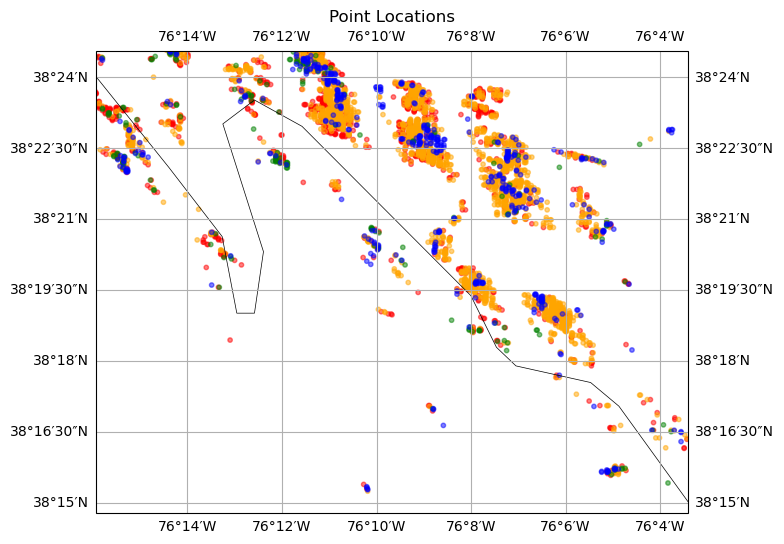

<Figure size 640x480 with 0 Axes>

In [27]:
# create a figure with one geographic subplot
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})

ax.scatter(
    x=df['lon'],
    y=df['lat'],  # FIXED here
    c=df['color'],
    s=10,
    alpha = 0.5,
    transform=ccrs.PlateCarree()
)


# vulnerable subregion (0-20000): 2022_ngs_ches_bay_topobathy_DEM_J1221339tR0_C0
ax.set_extent([-76.0568, -76.2656,
              38.4093, 38.2464],
              crs=ccrs.PlateCarree())


# ax.set_extent([-76.27075, -76.34282,
#                38.49984, 38.45112],
#               crs=ccrs.PlateCarree())


# # Shared extent for all subplots (ROI)
# ax.set_extent([-76.35156992998947, -75.68415049639572,
#       38.19934796579719, 38.67479854331683],  crs=ccrs.PlateCarree())

#less vulnerable new subregion (target region)
# ax.set_extent([-75.9, -75.68415049639572,
#       38.24288586938473, 38.45],  crs=ccrs.PlateCarree())

# #from new elevation tif (0-20000): 2022_ngs_ches_bay_topobathy_DEM_J1251990tR2_C1
# ax.set_extent([-76.0309, -75.8038,
#      38.1994, 38.3329],  crs=ccrs.PlateCarree())


# add map features
ax.coastlines(resolution='10m', linewidth=0.5)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# labels and title
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Point Locations')

plt.show()
plt.savefig('/home/jovyan/sara_typrin/ndvi_landsat/figures/category_subset_map_0_20000.png')


## 4. Show relative distribution of pathways 

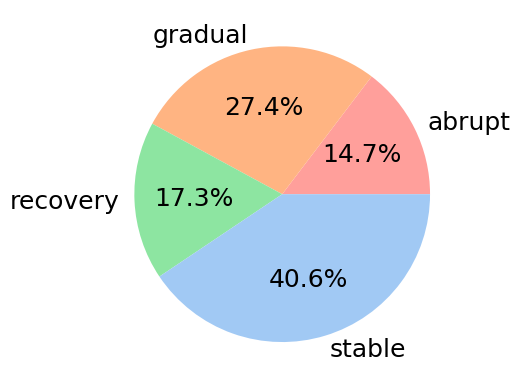

<Figure size 640x480 with 0 Axes>

In [45]:
# Define unique pathways and colors (you can customize colors if needed)
pathways = ['abrupt', 'gradual', 'recovery', 'stable']
counts = [
    len(df[df.pathway == 'abrupt']),
    len(df[df.pathway == 'gradual']),
    len(df[df.pathway == 'recovery']),
    len(df[df.pathway == 'stable'])
]
colors = [sns.color_palette("pastel")[3], sns.color_palette("pastel")[1], sns.color_palette("pastel")[2], sns.color_palette("pastel")[0]] # Matching the pathway order

# Plot the bar chart
plt.pie(counts, labels=pathways,  colors = colors, textprops={'fontsize': 18}, autopct='%.1f%%');
values = pd.Series([False, False, True, True])
v_counts = values.value_counts()
fig = plt.figure()

## 5. Plot all datapoints (iresspective of forest response path)

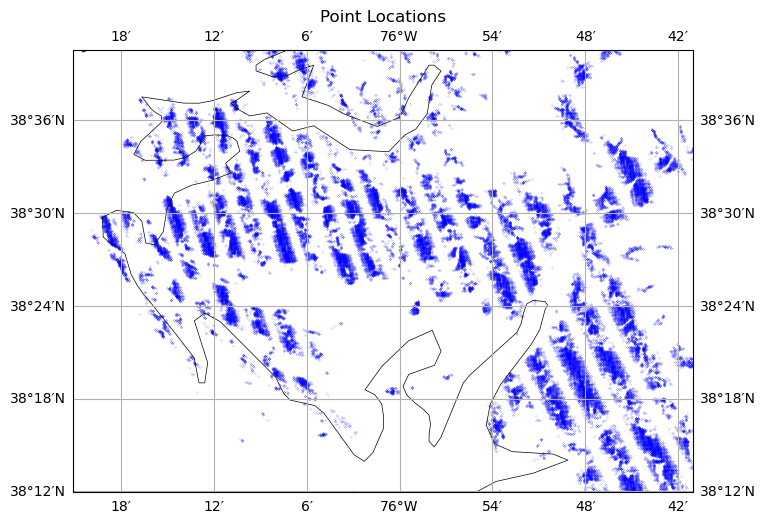

<Figure size 640x480 with 0 Axes>

In [47]:
# Scatter plot of points

# create a figure with one geographic subplot
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# plot the point data
ax.scatter(all_response_pathways['lon'], all_response_pathways['lat'],
           color='blue', s=0.01,
           transform=ccrs.PlateCarree())

# set map extent
ax.set_extent([-76.35156992998947, -75.68415049639572,
               38.19934796579719, 38.67479854331683],
              crs=ccrs.PlateCarree())

# add map features
ax.coastlines(resolution='10m', linewidth=0.5)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# labels and title
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Point Locations')

plt.show()
plt.savefig('/home/jovyan/sara_typrin/ndvi_landsat/figures/matched_coords_map.png')



### 6.  Plot points classified as upland forest 

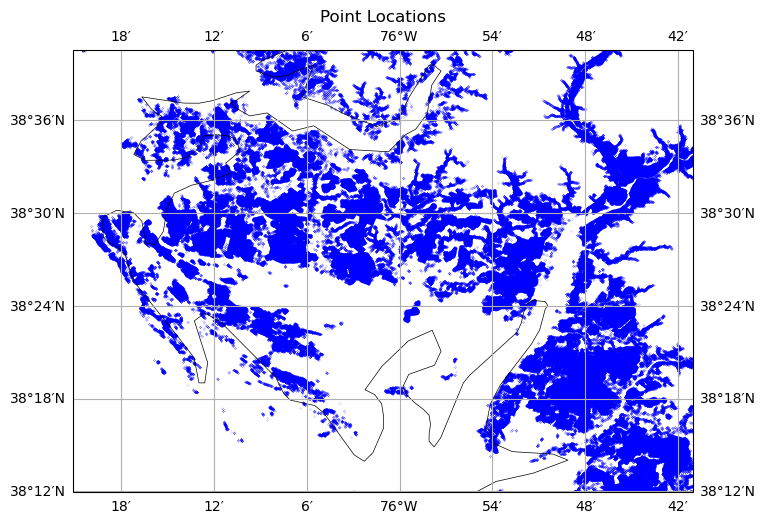

<Figure size 640x480 with 0 Axes>

In [60]:

# create a figure with one geographic subplot
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# plot the point data
ax.scatter(coords_df['lon'], coords_df['lat'],
           color='blue', s=0.01,
           transform=ccrs.PlateCarree())

# set map extent
ax.set_extent([-76.35156992998947, -75.68415049639572,
               38.19934796579719, 38.67479854331683],
              crs=ccrs.PlateCarree())

# add map features
ax.coastlines(resolution='10m', linewidth=0.5)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# labels and title
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Point Locations')

plt.show()
plt.savefig('/home/jovyan/sara_typrin/ndvi_landsat/figures/upland_forest_map.png')


In [61]:

# # Identify River to Show: 
# shp = shapereader.natural_earth(
#     resolution='10m',
#     category='physical',
#     name='rivers_lake_centerlines')
    

# reader = shapereader.Reader(shp)
# for record in reader.records():
#     name = record.attributes.get('name', '')
#     if name == ' Nanticoke River':
#         geom = record.geometry
#         ax.add_geometries([geom],
#                           crs=ccrs.PlateCarree(),
#                           edgecolor='blue',
#                           facecolor='none',
#                           linewidth=1.2)

# rivers = cfeature.NaturalEarthFeature(
#     category='physical',
#     name='rivers_lake_centerlines',
#     scale='10m',
#     edgecolor='blue',
#     facecolor='none'
# )
# #ax.add_feature(rivers, linewidth=1.2, zorder=5)

# 7. Make 4 Panel Figure for Region of Interest

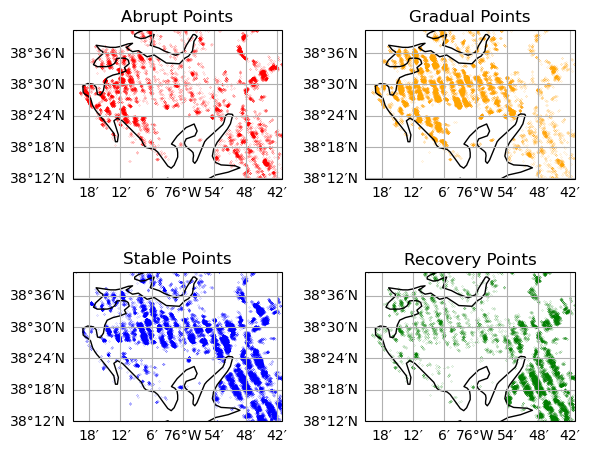

<Figure size 640x480 with 0 Axes>

In [55]:
# Set up a 2×2 figure with PlateCarree projection on each subplot

fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(6, 5),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Flatten axes array for easy iteration
axes = axes.flatten()

# List of datasets and their colors/titles
datasets = [
    (abrupt, 'red', 'Abrupt'),
    (gradual, 'orange', 'Gradual'),
    (stable, 'blue', 'Stable'),
    (recovery, 'green', 'Recovery'),
]

# Shared extent for all subplots
extent = [-76.35156992998947, -75.68415049639572,
          38.19934796579719, 38.67479854331683]

# Loop through axes and plot each dataset
for ax, (data, color, name) in zip(axes, datasets):
    ax.scatter(data['lon'], data['lat'],
               color=color, s=0.01,
               transform=ccrs.PlateCarree())
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines(resolution='10m', linewidth=1)
    # ax.add_feature(cfeature.RIVERS.with_scale('10m'),
    #            edgecolor='blue', linewidth=1.2, zorder=5) 
    ax.add_feature(cfeature.RIVERS.with_scale('10m'),lw=1)##### Add river ######
    gl = ax.gridlines(draw_labels=True, dms=True,
                      x_inline=False, y_inline=False)
    # Only label leftmost and bottom axes
    gl.top_labels = False
    gl.right_labels = False

    ax.set_title(f'{name} Points')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

# Improve spacing
plt.tight_layout()
plt.show()
plt.savefig('/home/jovyan/sara_typrin/ndvi_landsat/figures/4_panel_map.png')

In [56]:

# Load coastline shapefile
coastline_shapefile = shpreader.natural_earth(
    resolution='10m', category='physical', name='coastline'
)
reader = shpreader.Reader(coastline_shapefile)
coastlines = list(reader.records())

coastline_points = []
for record in coastlines:
    for geometry in record.geometry:
        coords = list(geometry.exterior.coords)
        coastline_points.extend(coords)

NameError: name 'shpreader' is not defined